In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector

In [2]:
circuit = QuantumCircuit(2,2)

In [3]:
circuit.draw()

q_0: 
     
q_1: 
     
c: 2/

In [4]:
%matplotlib inline

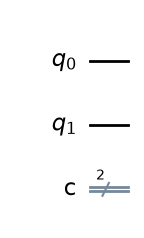

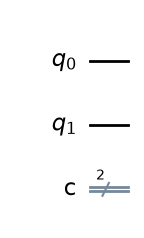

In [5]:
circuit.draw(output="mpl")

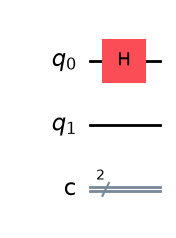

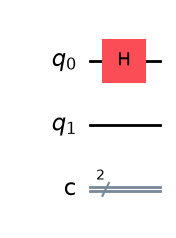

In [6]:
circuit.h(0)
circuit.draw(output="mpl")

In [7]:
circuit.cx(0,1)
state = Statevector(circuit)
circuit.measure([0,1],[0,1])

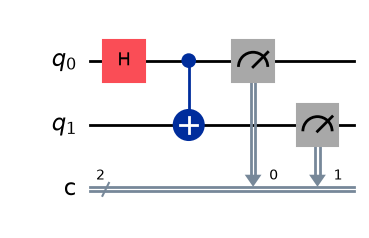

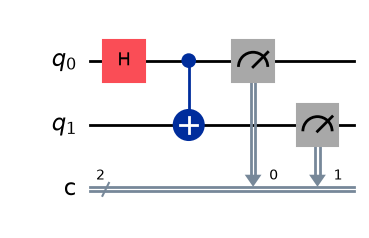

In [8]:
circuit.draw(output="mpl")

# Local Simulator

In [9]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

In [10]:
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots = 1024).result()

### Visualization

In [11]:
from qiskit.visualization import plot_histogram, plot_state_qsphere

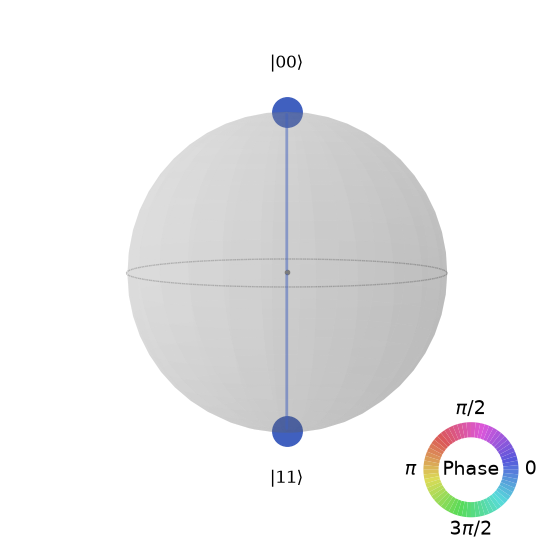

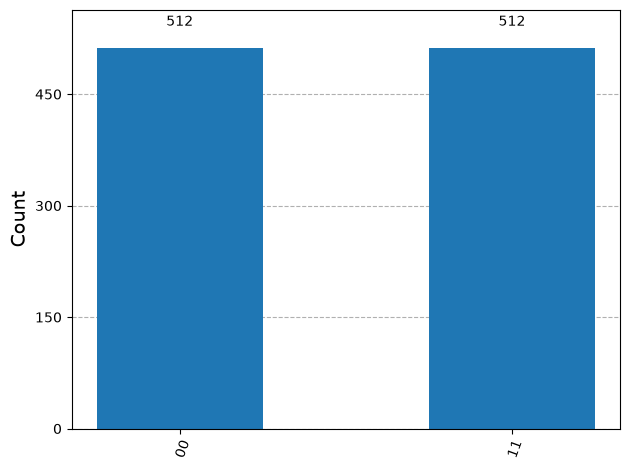

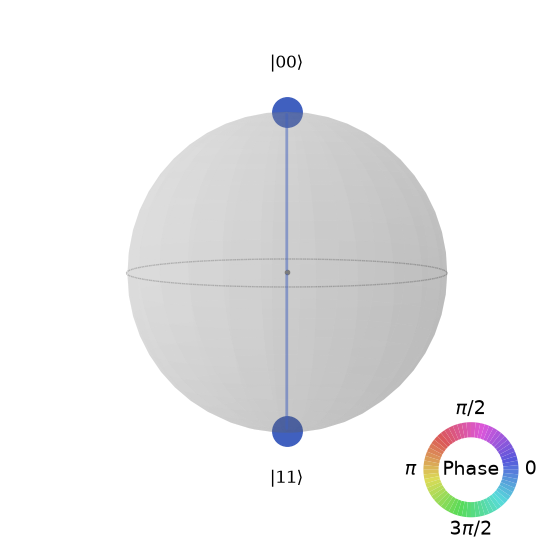

In [12]:
counts = result.get_counts(circuit)
plot_histogram(counts)
state.draw('qsphere')

# Running On Real IBM Hardware

In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="ENTER YOUR OWN API KEY",
    instance="ENTER YOUR OWN INSTANCE NAME",
    overwrite=True
)

service = QiskitRuntimeService()

In [14]:
print("Available backends:")
for backend in service.backends():
    print(" -", backend.name)

Available backends:
 - ibm_fez
 - ibm_kingston
 - ibm_marrakesh


In [15]:
quantum_computer = service.least_busy(operational=True, simulator=False)

In [16]:
print("Selected Backend:", quantum_computer.name)

Selected Backend: ibm_marrakesh


### Submitting the Job

In [17]:
from qiskit import transpile
from qiskit_ibm_runtime.executor_sampler import Sampler

In [18]:
isa_circuit = transpile(circuit, backend=quantum_computer, optimization_level=1)

sampler = Sampler(mode=quantum_computer)
job = sampler.run([isa_circuit], shots=1024)
print("Job ID:", job.job_id())

Job ID: dare3ddvr3kc73eiq6e0


In [19]:
print("Status Before Waiting:", job.status())
result = job.result()
print("Status After Waiting :", job.status())

Status Before Waiting: RUNNING
Status After Waiting : DONE


### Reading and Plotting the Results

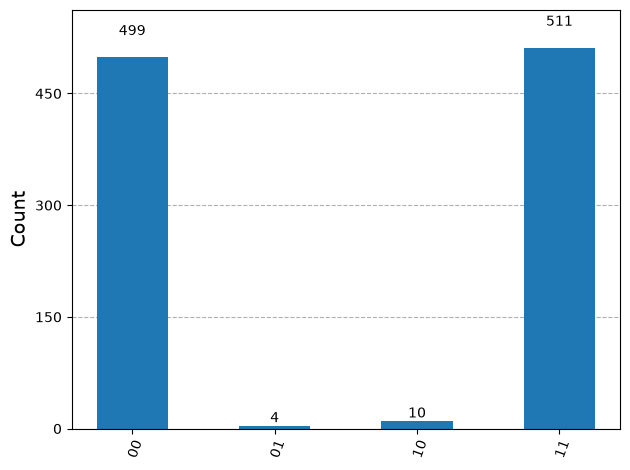

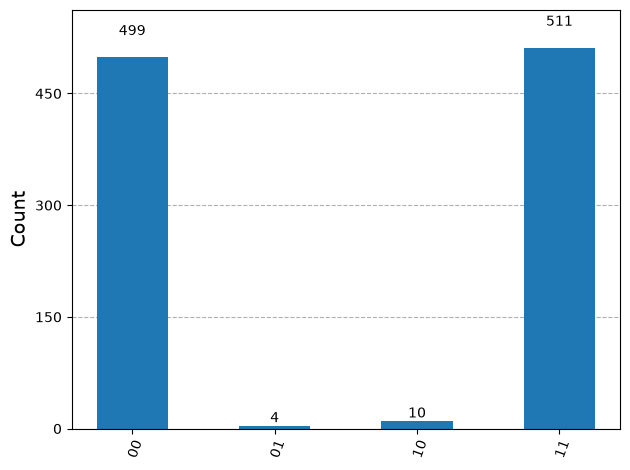

In [20]:
counts = result[0].data.c.get_counts()
plot_histogram(counts)